# Simple plots for GRL paper

In [62]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from scipy.stats import linregress
from scipy.stats import norm
from scipy.stats import gaussian_kde

import statsmodels.api as sm

In [2]:
global_dpath = '~/work/hist_sst/data/'

In [3]:
ceres_tsel = slice(2001,2023)

# Functions

In [4]:
def hac_trend(y, years=None, maxlags=2):
    y = np.asarray(y, dtype=float)

    if years is None:
        years = np.arange(len(y), dtype=float)
    else:
        years = np.asarray(years, dtype=float)

    mask = np.isfinite(y) & np.isfinite(years)
    y = y[mask]
    years = years[mask]

    ## center time so the intercept is the value near the middle of the period
    t = years - years.mean()

    ## fit y = a + b*t
    X = sm.add_constant(t)
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

    trend_per_year = fit.params[1]
    se_per_year = fit.bse[1]

    trend_per_decade = 10 * trend_per_year
    se_per_decade = 10 * se_per_year

    return {
        "trend_per_decade": trend_per_decade,
        "se_per_decade": se_per_decade,
        "ci90_per_decade": (
            trend_per_decade - 1.645 * se_per_decade,
            trend_per_decade + 1.645 * se_per_decade,
        ),
        "fit": fit,
    }

# ERF

In [5]:
path = 'indicators_climatechange/forcing-timeseries-6.3.1/output/'
fname = 'ERF_ensemble.nc'

In [6]:
%%time
ds_erf = (
    xr.open_dataset(global_dpath + path + fname, 
                    engine="netcdf4")
    .sel(time=slice(2000,2024))
)

erf_total = 0
for v in ds_erf.data_vars:
    erf_total = erf_total + ds_erf[v]

erf_total = erf_total.rename("total")

CPU times: user 811 ms, sys: 484 ms, total: 1.29 s
Wall time: 1.95 s


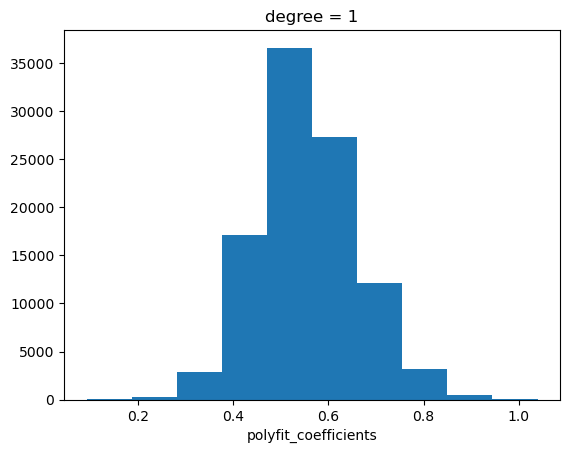

[0.398958   0.54754674 0.73782257]
<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.56)
Coordinates:
    degree   int64 8B 1 0.10401695441496547


In [7]:
dFdt = 10*erf_total.sel(time=ceres_tsel).polyfit(deg=1,dim='time').polyfit_coefficients[0]

dFdt.plot.hist()
plt.show()

print(dFdt.quantile([0.05,0.50, 0.95]).values)
print(dFdt.mean().round(2), dFdt.std().values)

In [8]:
## set parameters
dFdt_mu = dFdt.mean().values
dFdt_sig = dFdt.std(ddof=1).values
print(dFdt_mu.round(2), dFdt_sig.round(2))

0.56 0.1


## N (EEI): TOA imbalance

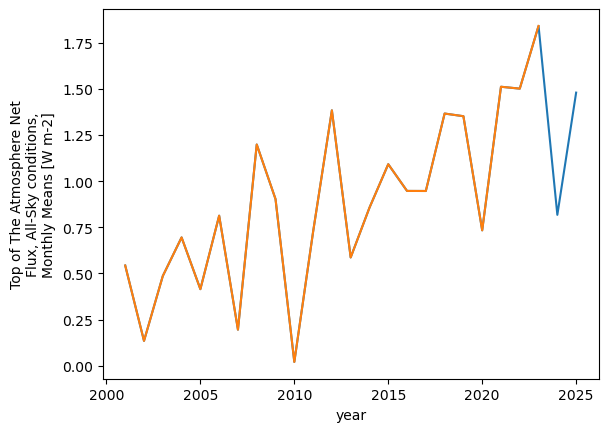

In [9]:
path = 'ceres_ebaf/ceres_ebaf/dl_20260602_globalmeanTOA/'
fname = 'CERES_EBAF_Ed4.2.1_Subset_200003-202512.nc'
ceres = xr.open_dataset(global_dpath + path + fname).sel(
    time=slice('2001-01-01','2025-12-31')).groupby('time.year').mean()
ceres['gtoa_net_all_mon'].plot()

ceres['gtoa_net_all_mon'].sel(year=ceres_tsel).plot()

N = ceres['gtoa_net_all_mon'].sel(year=ceres_tsel)

plt.show()

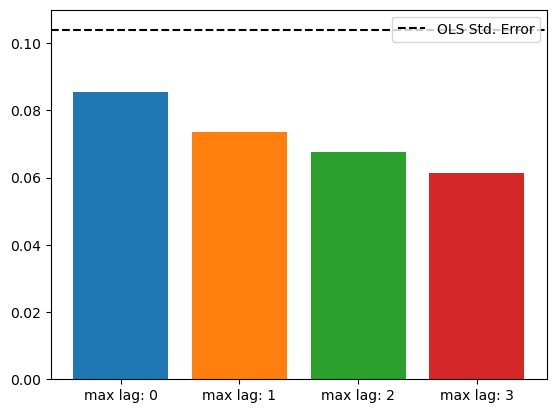

In [10]:
## no ensemble, so check std error of regression different ways

for i in np.arange(0,4,1):
    plt.bar(x='max lag: ' + str(i),height=hac_trend(N,maxlags=i)['se_per_decade'])

plt.axhline(linregress(N.year, N).stderr*10,c='k',label='OLS Std. Error',ls='--')
plt.legend()
plt.ylim(0,.11)
plt.show()

In [11]:
## set parameters
ols_N = linregress(N.year, N)
dNdt_mu = 10 * ols_N.slope
dNdt_sig = 10 * ols_N.stderr
print(dNdt_mu.round(2), dNdt_sig.round(2))

0.52 0.1


# Temperature

In [21]:
gmst_dict = {}

In [22]:
## Thorne
gmst_path = Path(global_dpath + "ar7-gmst-ensemble/sst_pseudo_ipcc.csv")

gmst_df = pd.read_csv(gmst_path, header=None)

gmst_ens = xr.DataArray(
    gmst_df.iloc[:, 1:].to_numpy(dtype="float32"),
    dims=("year", "ensemble"),
    coords={
        "year": gmst_df.iloc[:, 0].astype(int).to_numpy(),
        "ensemble": np.arange(gmst_df.shape[1] - 1),
    },
    name="gmst",
    attrs={"units": "degC", "baseline": "1850-1900"},
).sel(year=ceres_tsel)

gmst_dict['Thorne'] = gmst_ens

In [28]:
## HadCRUT5.1
## HadCRUT5 (should add)
path = global_dpath + 'other_recon/hadcrut5/'
fname = 'HadCRUT.5.1.0.0.analysis.ensemble_series.global.monthly.nc'
gmst_dict['HadCRUT5.1'] = (
    xr.open_dataset(path + fname)['tas']
    .sel(time=slice('2001-01-01','2025-12-31'))
    .groupby('time.year').mean().sel(year=ceres_tsel)
).rename({'realization':'ens'})

gmst_dict['HadCRUT5.1']

<xarray.DataArray 'tas' (ens: 200, year: 23)> Size: 37kB
array([[0.49662672, 0.53741708, 0.53343155, ..., 0.75296568, 0.76944539,
        1.10327949],
       [0.48377238, 0.51805041, 0.53147202, ..., 0.79115317, 0.7894848 ,
        1.10699201],
       [0.48640502, 0.53506828, 0.55500261, ..., 0.77603673, 0.8181999 ,
        1.10440103],
       ...,
       [0.50361812, 0.53349545, 0.54329597, ..., 0.79120943, 0.81511452,
        1.1149777 ],
       [0.48853593, 0.5338186 , 0.57660255, ..., 0.77438979, 0.81380523,
        1.09472718],
       [0.47725965, 0.54824253, 0.52117868, ..., 0.75325598, 0.83356543,
        1.11384827]], shape=(200, 23))
Coordinates:
  * ens        (ens) int64 2kB 1 2 3 4 5 6 7 8 ... 194 195 196 197 198 199 200
  * year       (year) int64 184B 2001 2002 2003 2004 ... 2020 2021 2022 2023
    latitude   float64 8B ...
    longitude  float64 8B ...
Attributes:
    long_name:     blended air_temperature_anomaly over land with sea_water_t...
    units:         K
    cell_methods:  area: mean (interval: 5.0 degrees_north 5.0 degrees_east) ...

In [31]:
## Cooper et al. 2025
path = global_dpath + 'public_share/ens_members/'
fname = 'ensmembers_tas_1850-2023.nc'
c25_load = xr.open_dataset(path + fname)['gmean'].sel(time=slice('2001-01-01','2024-01-01'))
c25_load = c25_load.rename({'ens':'ensemble'})
c25_tas = c25_load.groupby('time.year').mean(dim=['time']).stack(ens=['prior','ensemble'])

gmst_dict['C25'] = c25_tas


HadCRUT5.1
 0.22 0.006
0.211 0.219 0.229

Thorne
 0.229 0.013
0.214 0.226 0.252

C25
 0.239 0.022
0.203 0.24 0.28


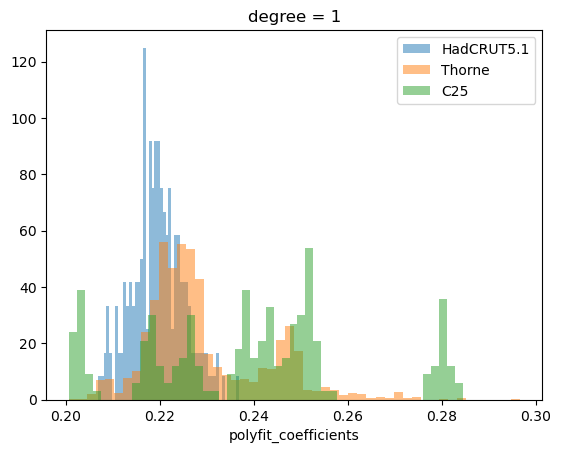

In [39]:
for key in ['HadCRUT5.1','Thorne','C25']:
    # dTdt = gmst_ens.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Thorne et al.',density=True)
    
    # dTdt = c25_tas.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Cooper et al. 2025',density=True)
    
    dTdt = 10*gmst_dict[key].polyfit(deg=1,dim='year').polyfit_coefficients[0]
    dTdt.plot.hist(bins=50,alpha=0.5,label=key,density=True)

    print('\n' + key + '\n', dTdt.mean().round(3).values, dTdt.std(ddof=1).round(3).values)
    print(dTdt.quantile(0.05).round(3).values, dTdt.quantile(0.5).round(3).values, dTdt.quantile(0.95).round(3).values)
plt.legend()
plt.show()

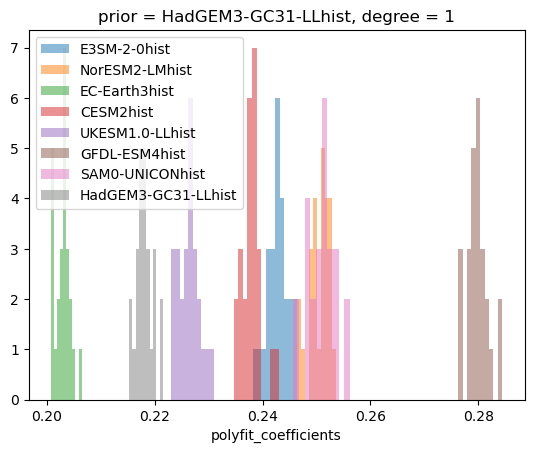

In [45]:
for i in range(8):
    temp = dTdt.unstack().isel(prior=i)
    temp.plot.hist(label=temp.prior.values,alpha=0.5)
plt.legend()
plt.show()

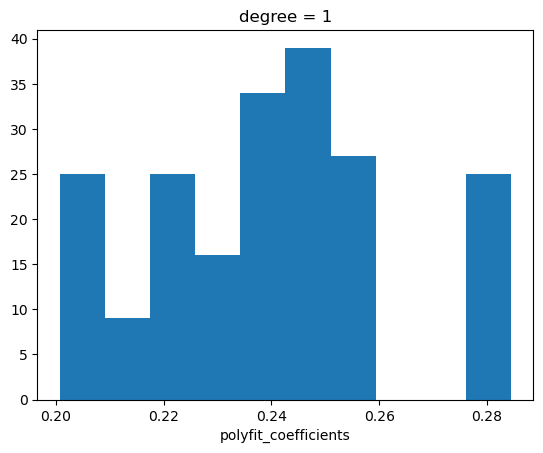

In [42]:
## choose middle
dTdt_mu  = 0.23
dTdt_sig = 0.013 # also matches BEST
dTdt.unstack().plot.hist()
plt.show()

# Pattern Effect

In [47]:
# from C25
dlamb_mu = 0.16 #median, mean is 0.136 for 2001-2023
dlamb_sig = 0.29 # all spread, including ic error
# cross model spread is ~0.15 #
#[should check cross model by doing cross model for the 3 BCs and pooling; could subtract IC spread]

# Monte Carlo

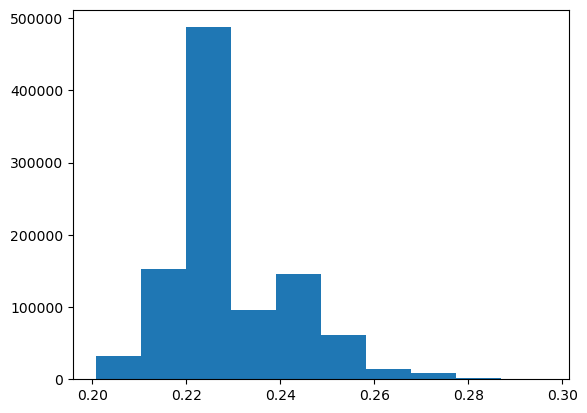

In [68]:
rng = np.random.default_rng(123)
mc_n = 1000000

## T
Tin = 10*gmst_dict['Thorne'].polyfit(deg=1,dim='year').polyfit_coefficients[0]
Tdot_ens = rng.choice(Tin, size=mc_n, replace=True)
plt.hist(Tdot_ens)
plt.show()

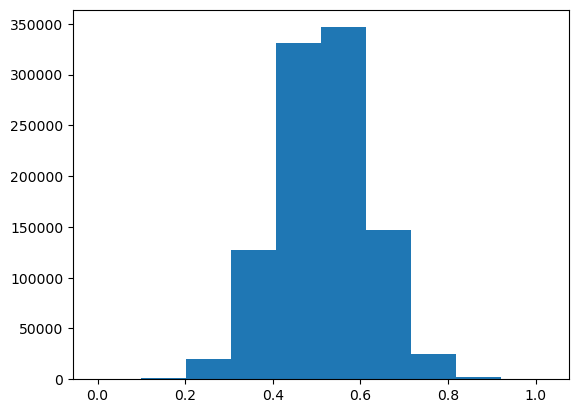

In [69]:
## N
Ndot_ens = rng.normal(loc=dNdt_mu, scale=dNdt_sig, size=mc_n)
plt.hist(Ndot_ens)
plt.show()

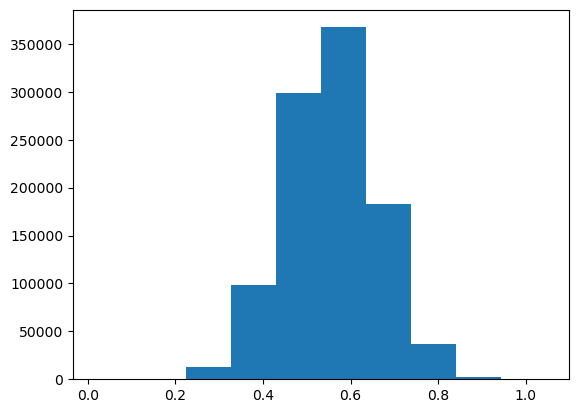

In [70]:
## F
Fdot_ens = rng.normal(loc=dFdt_mu, scale=dFdt_sig, size=mc_n)
plt.hist(Fdot_ens)
plt.show()

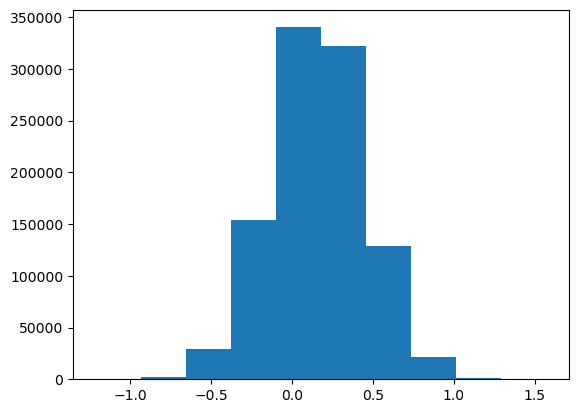

In [71]:
## dlamb
dlamb_ens = rng.normal(loc=dlamb_mu, scale=dlamb_sig, size=mc_n)
plt.hist(dlamb_ens)
plt.show()

In [72]:
## Likelihood

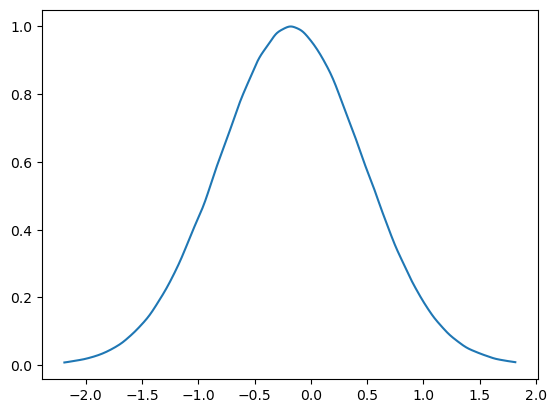

In [112]:
lam_ens = (Ndot_ens - Fdot_ens) / Tdot_ens + dlamb_ens
lam_ens = lam_ens[np.isfinite(lam_ens)]

kde = gaussian_kde(lam_ens)

lam_grid = np.linspace(*np.quantile(lam_ens, [0.001, 0.999]), 1000)
loglike = np.log(kde(lam_grid))
loglike -= loglike.max()  # optional normalization for plotting

plt.plot(lam_grid,np.exp(loglike))

/glade/derecho/scratch/vcooper/tmp/ipykernel_70253/2429201141.py:5: RuntimeWarning: divide by zero encountered in log
  loglike_S = np.log(kde(lam_from_S))


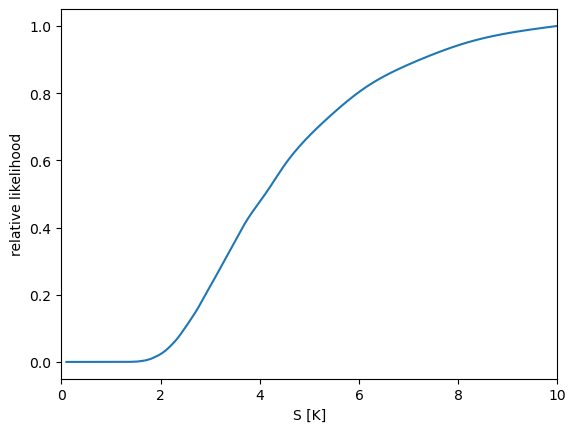

In [113]:
S_grid = np.linspace(0.1, 10, 500)  ## choose ECS range to plot

lam_from_S = -3.93 / S_grid

loglike_S = np.log(kde(lam_from_S))
loglike_S -= np.nanmax(loglike_S)

plt.plot(S_grid, np.exp(loglike_S))
plt.xlabel("S [K]")
plt.ylabel("relative likelihood")
plt.xlim(0,10)
plt.show()

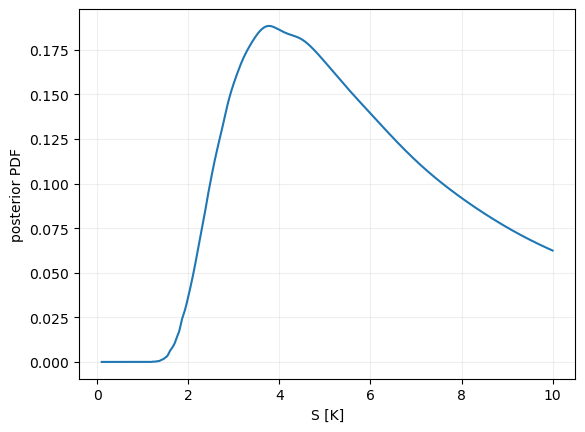

In [116]:
prior_mask = (lam_from_S >= -10) & (lam_from_S <= 10)

post_S = np.zeros_like(S_grid)
post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / S_grid[prior_mask]**2

## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)

plt.plot(S_grid, post_S)
plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
plt.xlim(0, 10)
plt.show()

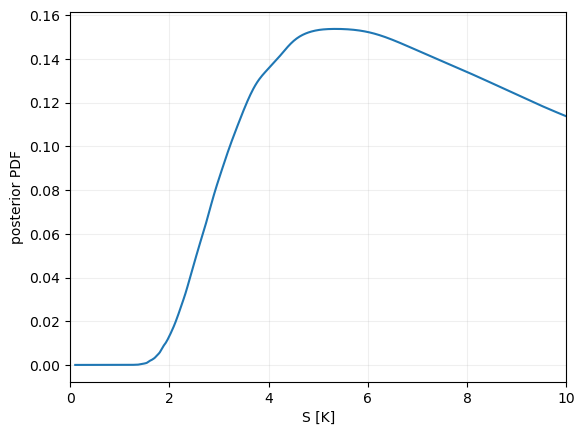

In [115]:
prior_mask = (lam_from_S >= -10) & (lam_from_S <= 10)

post_S = np.zeros_like(S_grid)
post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / S_grid[prior_mask]

## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)

plt.plot(S_grid, post_S)
plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
plt.xlim(0, 10)
plt.show()

## KEEP GOING HERE 
https://chatgpt.com/c/6a062dcc-fc3c-83ea-9593-37ce2aa718f3